In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns 

In [8]:
df=pd.read_csv("retail_store_inventory.csv")

In [9]:
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,01-01-2022,S001,P0001,Groceries,North,231,127,55,33.50,20,Rainy,0,29.69,Autumn
1,01-01-2022,S001,P0002,Toys,South,204,150,66,63.01,20,Sunny,0,66.16,Autumn
2,01-01-2022,S001,P0003,Toys,West,102,65,51,27.99,10,Sunny,1,31.32,Summer
3,01-01-2022,S001,P0004,Toys,North,469,61,164,32.72,10,Cloudy,1,34.74,Autumn
4,01-01-2022,S001,P0005,Electronics,East,166,14,135,73.64,0,Sunny,0,68.95,Summer


In [10]:
df.columns

Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Inventory Level', 'Units Sold', 'Units Ordered', 'Price', 'Discount',
       'Weather Condition', 'Holiday/Promotion', 'Competitor Pricing',
       'Seasonality'],
      dtype='object')

In [11]:
df.shape

(73100, 14)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                73100 non-null  object 
 1   Store ID            73100 non-null  object 
 2   Product ID          73100 non-null  object 
 3   Category            73100 non-null  object 
 4   Region              73100 non-null  object 
 5   Inventory Level     73100 non-null  int64  
 6   Units Sold          73100 non-null  int64  
 7   Units Ordered       73100 non-null  int64  
 8   Price               73100 non-null  float64
 9   Discount            73100 non-null  int64  
 10  Weather Condition   73100 non-null  object 
 11  Holiday/Promotion   73100 non-null  int64  
 12  Competitor Pricing  73100 non-null  float64
 13  Seasonality         73100 non-null  object 
dtypes: float64(2), int64(5), object(7)
memory usage: 7.8+ MB


In [13]:
# Convert date
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

# Convert categorical columns
cat_cols = ['Store ID','Product ID','Category','Region',
            'Weather Condition','Seasonality']

for col in cat_cols:
    df[col] = df[col].astype('category')

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                73100 non-null  datetime64[ns]
 1   Store ID            73100 non-null  category      
 2   Product ID          73100 non-null  category      
 3   Category            73100 non-null  category      
 4   Region              73100 non-null  category      
 5   Inventory Level     73100 non-null  int64         
 6   Units Sold          73100 non-null  int64         
 7   Units Ordered       73100 non-null  int64         
 8   Price               73100 non-null  float64       
 9   Discount            73100 non-null  int64         
 10  Weather Condition   73100 non-null  category      
 11  Holiday/Promotion   73100 non-null  int64         
 12  Competitor Pricing  73100 non-null  float64       
 13  Seasonality         73100 non-null  category  

In [15]:
df.isnull().sum()

Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Price                 0
Discount              0
Weather Condition     0
Holiday/Promotion     0
Competitor Pricing    0
Seasonality           0
dtype: int64

In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df.describe()

,Date,Inventory Level,Units Sold,Units Ordered,Price,Discount,Holiday/Promotion,Competitor Pricing
count,73100,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000
mean,2022-12-31 23:59:59.999999744,274.469877,136.464870,110.004473,55.135108,10.009508,0.497305,55.146077
min,2022-01-01 00:00:00,50.000000,0.000000,20.000000,10.000000,0.000000,0.000000,5.030000
25%,2022-07-02 00:00:00,162.000000,49.000000,65.000000,32.650000,5.000000,0.000000,32.680000
50%,2023-01-01 00:00:00,273.000000,107.000000,110.000000,55.050000,10.000000,0.000000,55.010000
75%,2023-07-03 00:00:00,387.000000,203.000000,155.000000,77.860000,15.000000,1.000000,77.820000
max,2024-01-01 00:00:00,500.000000,499.000000,200.000000,100.000000,20.000000,1.000000,104.940000
std,NaN,129.949514,108.919406,52.277448,26.021945,7.083746,0.499996,26.191408


In [18]:
print(f'Shape        : {df.shape}')
print(f'Date range   : {df["Date"].min().date()} → {df["Date"].max().date()}')
print(f'Stores       : {sorted(df["Store ID"].unique())}')
print(f'Sales range  : {df["Price"].min():.2f} – {df["Price"].max():.2f}')

Shape        : (73100, 14)
Date range   : 2022-01-01 → 2024-01-01
Stores       : ['S001', 'S002', 'S003', 'S004', 'S005']
Sales range  : 10.00 – 100.00


In [19]:
df['Category'].value_counts()

Category
Furniture      14699
Toys           14643
Clothing       14626
Groceries      14611
Electronics    14521
Name: count, dtype: int64

In [20]:
df['Region'].value_counts()

Region
East     18349
South    18297
North    18228
West     18226
Name: count, dtype: int64

In [21]:
df['Seasonality'].value_counts()

Seasonality
Spring    18317
Summer    18305
Winter    18285
Autumn    18193
Name: count, dtype: int64

In [22]:
df['Weather Condition'].value_counts()

Weather Condition
Sunny     18290
Rainy     18278
Snowy     18272
Cloudy    18260
Name: count, dtype: int64

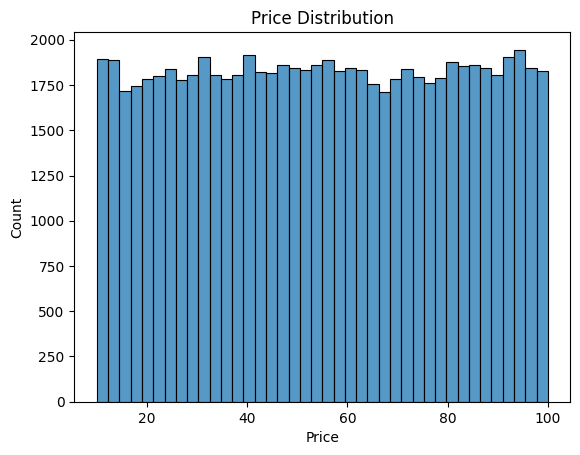

In [23]:
sns.histplot(df['Price'], bins=40)
plt.title("Price Distribution")
plt.show()

In [24]:
df['month'] = df['Date'].dt.month
df['day_name'] = df['Date'].dt.day_name()

# Revenue 
df['Revenue'] = df['Units Sold'] * df['Price']

In [25]:
# Total Business Performance
print("Total Units Sold:", df['Units Sold'].sum())
print("Total Revenue:", df['Revenue'].sum())

Total Units Sold: 9975582
Total Revenue: 550228884.91


In [26]:
df.groupby('Category', observed=True)['Units Sold'].sum().sort_values(ascending=False)

Category
Furniture      2025017
Groceries      2000482
Clothing       1999166
Toys           1990485
Electronics    1960432
Name: Units Sold, dtype: int64

In [27]:
df['Revenue'] = df['Units Sold'] * df['Price']

df.groupby('Category', observed=True)['Revenue'].sum().sort_values(ascending=False)

Category
Furniture      1.115118e+08
Groceries      1.109845e+08
Clothing       1.096510e+08
Toys           1.096424e+08
Electronics    1.084391e+08
Name: Revenue, dtype: float64

In [28]:
df.groupby('Region', observed=True)['Units Sold'].sum()

Region
East     2511265
North    2484966
South    2507799
West     2471552
Name: Units Sold, dtype: int64

In [29]:
df.groupby('Seasonality', observed=True)['Units Sold'].mean()

Seasonality
Autumn    137.782444
Spring    135.826828
Summer    135.428298
Winter    136.830790
Name: Units Sold, dtype: float64

In [30]:
df.groupby('Weather Condition', observed=True)['Units Sold'].mean()

Weather Condition
Cloudy    136.758324
Rainy     135.160028
Snowy     135.911559
Sunny     138.028650
Name: Units Sold, dtype: float64

In [31]:
print(df.groupby('Category', observed=True)['Units Sold'].sum().sort_values())


Category
Electronics    1960432
Toys           1990485
Clothing       1999166
Groceries      2000482
Furniture      2025017
Name: Units Sold, dtype: int64


In [32]:
print(df.groupby('Region', observed=True)['Units Sold'].sum().sort_values(ascending=False))


Region
East     2511265
South    2507799
North    2484966
West     2471552
Name: Units Sold, dtype: int64


In [33]:
print(df.groupby('Seasonality', observed=True)['Units Sold'].mean().sort_values(ascending=False))


Seasonality
Autumn    137.782444
Winter    136.830790
Spring    135.826828
Summer    135.428298
Name: Units Sold, dtype: float64


In [34]:
print(df.groupby('Weather Condition', observed=True)['Units Sold'].mean().sort_values(ascending=False))

Weather Condition
Sunny     138.028650
Cloudy    136.758324
Snowy     135.911559
Rainy     135.160028
Name: Units Sold, dtype: float64


In [35]:
# average revenue per transaction
df['Revenue'] = df['Units Sold'] * df['Price']

df['Revenue'].mean()

np.float64(7527.070929001367)

In [36]:
promo_sales = df[df['Holiday/Promotion'] == 1]['Units Sold'].sum()
total_sales = df['Units Sold'].sum()

(promo_sales / total_sales) * 100

np.float64(49.71558551671472)

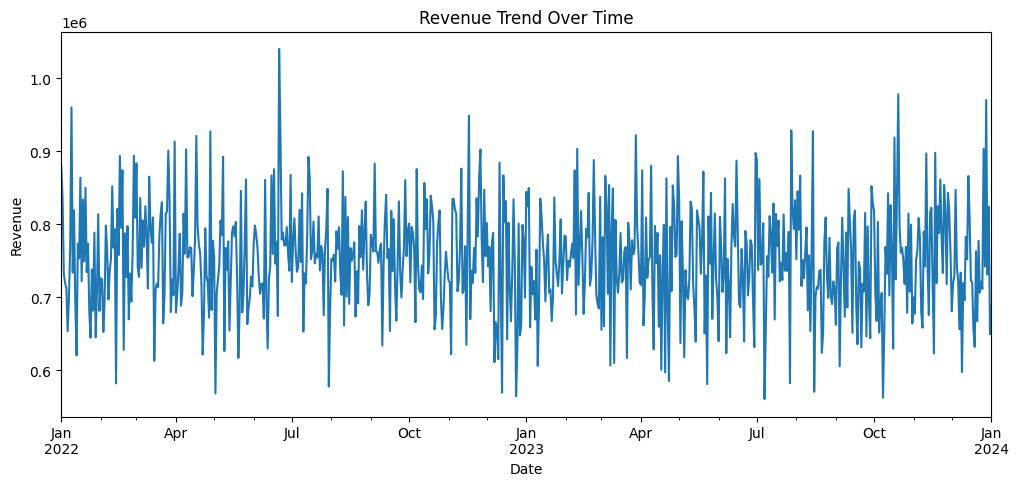

In [37]:
df['Revenue'] = df['Units Sold'] * df['Price']

df.groupby('Date')['Revenue'].sum().plot(figsize=(12,5))
plt.title("Revenue Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.show()

In [38]:
print(df.groupby('day_name')['Units Sold'].mean())

day_name
Friday       136.851442
Monday       135.094667
Saturday     135.314476
Sunday       136.809714
Thursday     137.281923
Tuesday      137.307692
Wednesday    136.615096
Name: Units Sold, dtype: float64


In [60]:
df.dtypes

Store ID                int64
Product ID              int64
Category                int64
Region                  int64
Inventory Level         int64
Units Sold              int64
Units Ordered           int64
Price                 float64
Discount                int64
Weather Condition       int64
Holiday/Promotion       int64
Competitor Pricing    float64
Seasonality             int64
month                   int32
day_name                int64
day                     int32
week                    int64
Price_Gap             float64
Discount_Flag           int64
Units_Sold_Lag1       float64
Units_Sold_Lag7       float64
Units_Sold_Lag30      float64
Rolling_Mean_7        float64
Rolling_Mean_30       float64
dtype: object

In [41]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score


In [42]:
label_encoders = {}

cols_to_encode = ['Store ID', 'Product ID', 'Category',
                  'Region', 'Weather Condition', 'Seasonality', 'day_name']

for col in cols_to_encode:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

# Verify encoding done
print("After Encoding:")
print(df.dtypes)

After Encoding:
Store ID                int64
Product ID              int64
Category                int64
Region                  int64
Inventory Level         int64
Units Sold              int64
Units Ordered           int64
Price                 float64
Discount                int64
Weather Condition       int64
Holiday/Promotion       int64
Competitor Pricing    float64
Seasonality             int64
month                   int32
day_name                int64
Revenue               float64
day                     int32
week                    int64
dtype: object


In [ ]:
df['Price_Gap']      = df['Price'] - df['Competitor Pricing']
df['Discount_Flag']  = (df['Discount'] > 0).astype(int)

In [62]:
df=df.sort_values(['Store ID','Product ID']).reset_index(drop=True)

In [54]:
df['Units_Sold_Lag1']  = df.groupby(['Store ID','Product ID'])['Units Sold'].shift(1)
df['Units_Sold_Lag7']  = df.groupby(['Store ID','Product ID'])['Units Sold'].shift(7)
df['Units_Sold_Lag30'] = df.groupby(['Store ID','Product ID'])['Units Sold'].shift(30)

df['Rolling_Mean_7']  = df.groupby(['Store ID','Product ID'])['Units Sold'].transform(
                         lambda x: x.rolling(window=7,  min_periods=1).mean())
df['Rolling_Mean_30'] = df.groupby(['Store ID','Product ID'])['Units Sold'].transform(
                         lambda x: x.rolling(window=30, min_periods=1).mean())

In [63]:
df = df.dropna()
print("\nShape after dropna:", df.shape)


Shape after dropna: (70070, 24)


In [65]:
X = df.drop(columns=['Units Sold'])
y = df['Units Sold']

print("\nFeatures:", X.shape)
print("Target  :", y.shape)
print(X.columns.tolist())


Features: (70070, 23)
Target  : (70070,)
['Store ID', 'Product ID', 'Category', 'Region', 'Inventory Level', 'Units Ordered', 'Price', 'Discount', 'Weather Condition', 'Holiday/Promotion', 'Competitor Pricing', 'Seasonality', 'month', 'day_name', 'day', 'week', 'Price_Gap', 'Discount_Flag', 'Units_Sold_Lag1', 'Units_Sold_Lag7', 'Units_Sold_Lag30', 'Rolling_Mean_7', 'Rolling_Mean_30']


In [68]:
tscv  = TimeSeriesSplit(n_splits=5)
model = RandomForestRegressor(n_estimators=200,
                               random_state=42,
                               n_jobs=-1)

mae_scores  = []
rmse_scores = []
r2_scores   = []

for fold, (train_index, test_index) in enumerate(tscv.split(X)):

    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)

    mae_scores.append(mae)
    rmse_scores.append(rmse)
    r2_scores.append(r2)

    print(f"Fold {fold+1} → MAE: {mae:.2f} | RMSE: {rmse:.2f} | R2: {r2:.2f}")

print("\n--- Final Model Performance ---")
print(f"Average MAE  : {np.mean(mae_scores):.2f}")
print(f"Average RMSE : {np.mean(rmse_scores):.2f}")
print(f"Average R2   : {np.mean(r2_scores):.2f}")

Fold 1 → MAE: 63.18 | RMSE: 81.76 | R2: 0.44
Fold 2 → MAE: 62.54 | RMSE: 80.88 | R2: 0.45
Fold 3 → MAE: 63.08 | RMSE: 81.18 | R2: 0.45
Fold 4 → MAE: 62.30 | RMSE: 80.22 | R2: 0.45
Fold 5 → MAE: 63.55 | RMSE: 81.66 | R2: 0.45

--- Final Model Performance ---
Average MAE  : 62.93
Average RMSE : 81.14
Average R2   : 0.45
